## Preprocesamiento de Imágenes
## G1: Joaquín Batista, Milagros Cancela, Valentín Rodríguez, Alexia Aurrecoechea, Nahuel López
**Ingeniería de Datos — Universidad Católica del Uruguay**
---

## 🎯 Objetivo  
Implementar un pipeline de preprocesamiento de imágenes:  
- Representación  
- Espacios de color  
- Contraste (global vs adaptativo)  
- Suavizado  
- Detección y descripción de *features* con visualización y métricas  

---

## 📚 Lecturas mínimas (recordatorio)

- **Fundamentos de espacios de color:** RGB, HSV/HSL y CIE Lab*  
- **Contraste:** ecualización de histograma vs CLAHE (adaptativa)  
- **Esquinas y puntos de interés:** Harris, Shi–Tomasi; detectores/desciptores tipo ORB/SIFT  
- **Métricas y diagnóstico:** histogramas, gradientes y repetibilidad de *features*


## Setup y Carga de Datos  

In [3]:
!pip3 install -q opencv-python opencv-contrib-python numpy matplotlib scikit-image pandas --break-system-packages

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import exposure, filters, feature, color, img_as_float
import skimage
import pathlib, warnings, platform, os
warnings.filterwarnings('ignore')

print("✅ Librerías listas")
print(f"OpenCV: {cv2.__version__}")
print(f"scikit-image: {skimage.__version__}")
print(f"Python: {platform.python_version()}")

✅ Librerías listas
OpenCV: 4.12.0
scikit-image: 0.25.2
Python: 3.13.5


0) Dataset de ejemplo (descarga automática)

Opción A (rápida, 10–15 imágenes clásicas): usa imágenes de scikit-image

In [4]:
from skimage import data as skdata, io as skio

RAW_DIR = pathlib.Path("data/raw")
RAW_DIR.mkdir(parents=True, exist_ok=True)

samples_sk = {
    "camera.png": skdata.camera(),
    "astronaut.png": skdata.astronaut(),
    "coffee.png": skdata.coffee(),
    "coins.png": skdata.coins(),
    "checkerboard.png": skdata.checkerboard(),
    "rocket.png": skdata.rocket(),
    "page.png": skdata.page()
}

for name, img in samples_sk.items():
    out = RAW_DIR / name
    skio.imsave(out.as_posix(), img)

print("✅ Pack mínimo descargado en", RAW_DIR)

✅ Pack mínimo descargado en data/raw


1) Directorios y listado de imágenes

In [5]:
DATA_DIR = pathlib.Path("data/raw")
SAMPLES_DIR = pathlib.Path("data/samples")
OUTPUTS = {
    "preproc": pathlib.Path("outputs/preproc"),
    "features": pathlib.Path("outputs/features"),
    "metrics": pathlib.Path("outputs/metrics"),
}
for p in OUTPUTS.values():
    p.mkdir(parents=True, exist_ok=True)

images = sorted([p for p in DATA_DIR.glob("**/*")
                 if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}])
print("Imágenes encontradas:", len(images))
images[:5]

Imágenes encontradas: 7


[PosixPath('data/raw/astronaut.png'),
 PosixPath('data/raw/camera.png'),
 PosixPath('data/raw/checkerboard.png'),
 PosixPath('data/raw/coffee.png'),
 PosixPath('data/raw/coins.png')]

## Parte A — Representación e inspección inicial  
### A.1 Matriz y formato

In [6]:
from pathlib import Path

def read_image_bgr(path: Path):
    img_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    assert img_bgr is not None, f"No se pudo leer: {path}"
    return img_bgr

img_path = images[0]
img_bgr = read_image_bgr(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

height, width = img_gray.shape[:2]
channels = img_rgb.shape[2] if img_rgb.ndim == 3 else 1
dtype = img_bgr.dtype
min_val, max_val = int(img_gray.min()), int(img_gray.max())
mean_gray = float(img_gray.mean())

print("H, W, C:", height, width, channels)
print("dtype:", dtype, "rango:", (min_val, max_val), "mean_gray:", round(mean_gray, 2))

H, W, C: 512 512 3
dtype: uint8 rango: (0, 255) mean_gray: 115.41


A.2 Histogramas (diagnóstico)

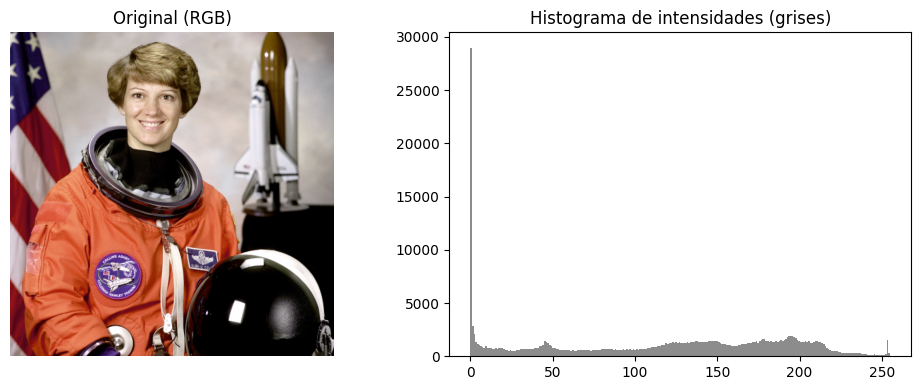

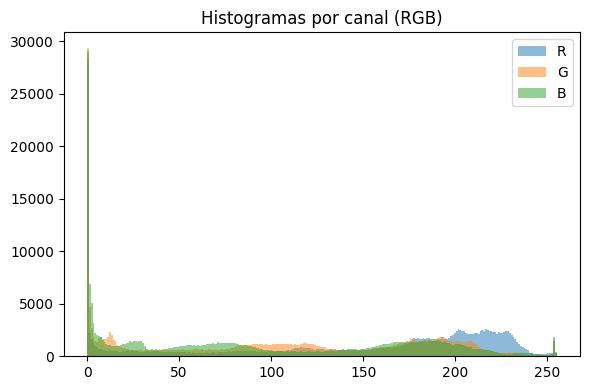

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_rgb); axes[0].set_title("Original (RGB)"); axes[0].axis("off")

axes[1].hist(img_gray.ravel(), bins=256, range=(0, 255), color="gray", alpha=0.9)
axes[1].set_title("Histograma de intensidades (grises)")
plt.tight_layout(); plt.show()

# Si es color: histogramas por canal
colors = ("R", "G", "B")
plt.figure(figsize=(6,4))
for i, c in enumerate(colors):
    plt.hist(img_rgb[..., i].ravel(), bins=256, range=(0, 255), alpha=0.5, label=c)
plt.legend(); plt.title("Histogramas por canal (RGB)"); plt.tight_layout(); plt.show()

## 📝 Preguntas de reflexión — Parte A

1) El rango dinámico observado fue de **0 a 255**.  
   Esto sugiere **una buena utilización del rango tonal completo, con presencia tanto de sombras como de zonas brillantes**.

2) El histograma indica **alto contraste** porque **los valores de intensidad están distribuidos a lo largo de todo el rango, sin concentrarse únicamente en la zona media**.

3) En color, el canal con mayor dominancia fue **el rojo (R)**;  
   implicancia: **la imagen presenta un tinte cálido, típico de iluminación interior o atardeceres**.


## 🎨 Parte B — Espacios de color y contraste  
### B.1 Cambio de espacio

In [8]:
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)

salient_hsv_channel = "V"  # "H" | "S" | "V"
salient_lab_channel = "L"  # "L" | "A" | "B"
print("Canales relevantes:", salient_hsv_channel, salient_lab_channel)

Canales relevantes: V L


STD contraste — before/eq/clahe: 75.12 80.25 75.87


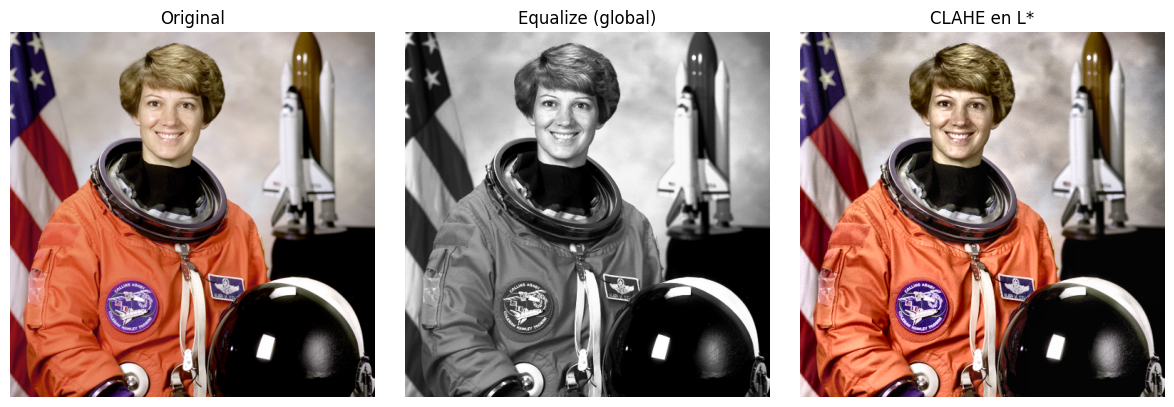

In [9]:
# Global en grises
eq_gray = cv2.equalizeHist(img_gray)

# CLAHE en L* (LAB)
L, A, B = cv2.split(img_lab)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
L_clahe = clahe.apply(L)
lab_clahe = cv2.merge([L_clahe, A, B])
rgb_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)

def contrast_std(x: np.ndarray) -> float:
    return float(np.std(x.astype(np.float32)))

std_before = contrast_std(img_gray)
std_eq = contrast_std(eq_gray)
std_clahe = contrast_std(cv2.cvtColor(rgb_clahe, cv2.COLOR_RGB2GRAY))
print("STD contraste — before/eq/clahe:", round(std_before,2), round(std_eq,2), round(std_clahe,2))

fig, axes = plt.subplots(1, 3, figsize=(12,4))
axes[0].imshow(img_rgb); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(eq_gray, cmap="gray"); axes[1].set_title("Equalize (global)"); axes[1].axis("off")
axes[2].imshow(rgb_clahe); axes[2].set_title("CLAHE en L*"); axes[2].axis("off")
plt.tight_layout(); plt.show()

## 📝 Preguntas de reflexión — Parte B

1) El canal más informativo fue **L (en LAB)** porque **representa directamente la luminancia, separando la información de brillo del color y permitiendo ajustar el contraste sin alterar la tonalidad**.

2) **CLAHE** mejoró **más** que la ecualización global en zonas homogéneas porque **realiza la ecualización de manera local, limitando la amplificación del ruido y evitando artefactos en regiones planas o de baja textura**.

3) El cambio en la **desviación estándar** sugiere **un aumento del contraste global, ya que una mayor dispersión de intensidades indica una expansión del rango tonal en la imagen**.


## 🔹 Parte C — Suavizado y bordes  
### C.1 Suavizado

In [10]:
gaussian = cv2.GaussianBlur(img_gray, ksize=(5, 5), sigmaX=0)
bilateral = cv2.bilateralFilter(img_gray, d=9, sigmaColor=75, sigmaSpace=75)

def grad_variance(x: np.ndarray) -> float:
    gx = cv2.Sobel(x, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(x, cv2.CV_32F, 0, 1, ksize=3)
    g = np.hypot(gx, gy)
    return float(np.var(g))

gv_before = grad_variance(img_gray)
gv_gauss = grad_variance(gaussian)
gv_bilat = grad_variance(bilateral)
print("Var(grad) — before/gauss/bilateral:", round(gv_before,2), round(gv_gauss,2), round(gv_bilat,2))

Var(grad) — before/gauss/bilateral: 10788.16 5335.25 5488.11


### C.2 Bordes

Edges ratio — before/gauss/bilateral: 0.078 0.052 0.038


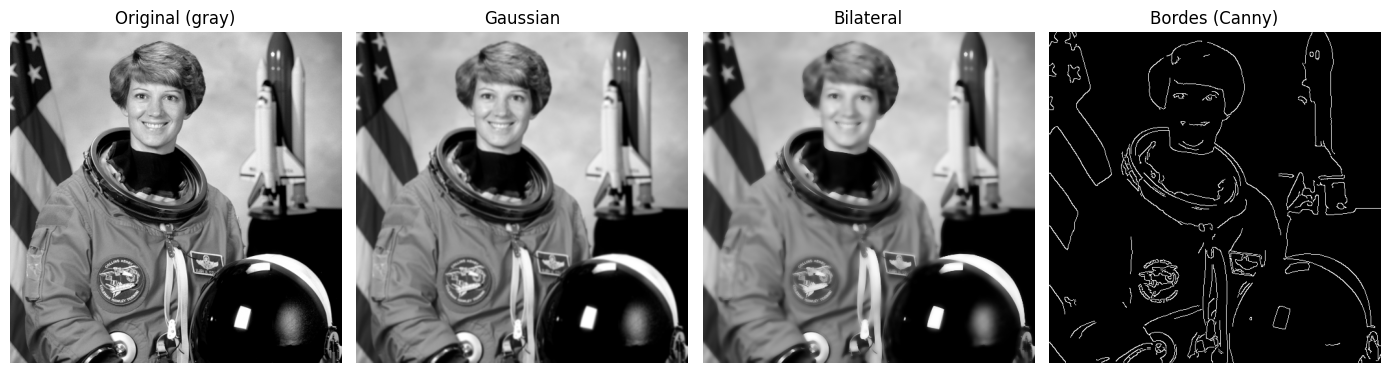

In [11]:
edges_before = cv2.Canny(img_gray, threshold1=100, threshold2=200)
edges_gauss = cv2.Canny(gaussian, threshold1=100, threshold2=200)
edges_bilat = cv2.Canny(bilateral, threshold1=100, threshold2=200)

def edge_ratio(x: np.ndarray) -> float:
    return float((x > 0).mean())

er_before = edge_ratio(edges_before)
er_gauss = edge_ratio(edges_gauss)
er_bilat = edge_ratio(edges_bilat)
print("Edges ratio — before/gauss/bilateral:", round(er_before,3), round(er_gauss,3), round(er_bilat,3))

fig, axes = plt.subplots(1, 4, figsize=(14,4))
axes[0].imshow(img_gray, cmap="gray"); axes[0].set_title("Original (gray)"); axes[0].axis("off")
axes[1].imshow(gaussian, cmap="gray"); axes[1].set_title("Gaussian"); axes[1].axis("off")
axes[2].imshow(bilateral, cmap="gray"); axes[2].set_title("Bilateral"); axes[2].axis("off")
axes[3].imshow(edges_bilat, cmap="gray"); axes[3].set_title("Bordes (Canny)"); axes[3].axis("off")
plt.tight_layout(); plt.show()

## 📝 Preguntas de reflexión — Parte C

1) El suavizado que mejor conservó bordes fue **el filtro bilateral** porque **reduce el ruido manteniendo los contornos nítidos al considerar tanto la distancia espacial como la diferencia de intensidad entre píxeles**.

2) El ratio de bordes sugiere **ruido** en la variante **gaussiana**,  
   ya que **suaviza de forma global y puede generar bordes falsos o poco definidos al difuminar zonas de transición**.

3) Cambiarías los **thresholds de Canny a (50, 100)** para escenas nocturnas porque **umbrales más bajos permiten detectar bordes más débiles en condiciones de baja iluminación, aunque incrementen ligeramente el ruido**.

## ⭐ Parte D — Puntos de interés y descriptores  
### 🎯 Objetivo: evidenciar cómo el preprocesamiento afecta cantidad y calidad de features locales.


### D.1 Detección en Variantes

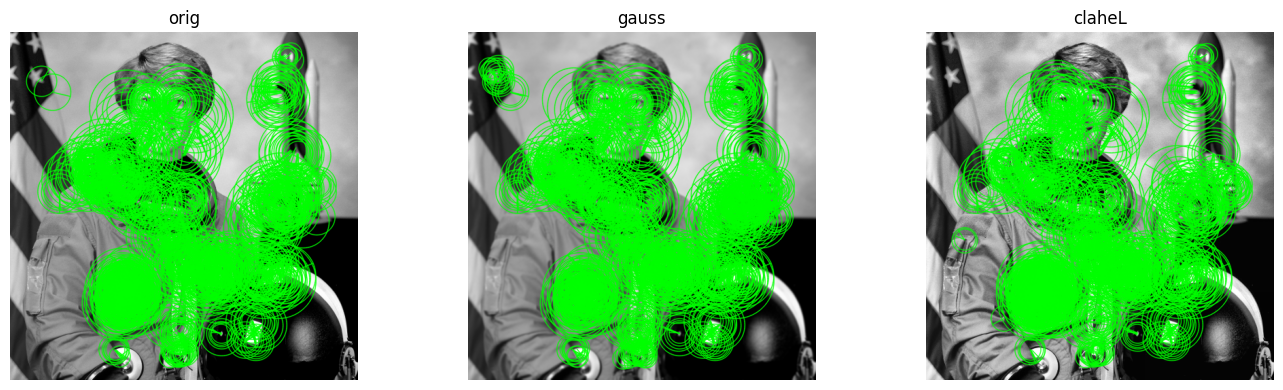

In [12]:
variants = {
    "orig": img_gray,
    "gauss": gaussian,
    "claheL": cv2.cvtColor(rgb_clahe, cv2.COLOR_RGB2GRAY)
}

# ORB (rápido, binario)
orb = cv2.ORB_create(nfeatures=1000, scaleFactor=1.2, nlevels=8)

kp_stats = []
overlay_examples = []
for name, img in variants.items():
    kp, des = orb.detectAndCompute(img, None)
    kp_stats.append({"variant": name, "num_keypoints": len(kp), "descriptor_size": 0 if des is None else des.shape[1]})
    out = cv2.drawKeypoints(img, kp, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS, color=(0,255,0))
    overlay_examples.append((name, out))

pd.DataFrame(kp_stats)
fig, axes = plt.subplots(1, len(overlay_examples), figsize=(14,4))
for ax, (name, out) in zip(axes, overlay_examples):
    ax.imshow(out, cmap="gray"); ax.set_title(name); ax.axis("off")
plt.tight_layout(); plt.show()

### D.2 Matching y repetibilidad (A vs A’)

#kp_orig: 1000 #kp_claheL: 1000 matches: 617 ratio: 0.62


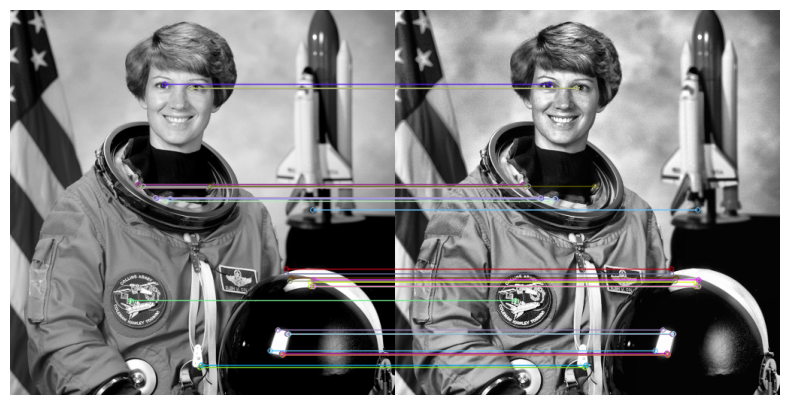

In [13]:
# Emparejar orig vs claheL con ORB
kp1, des1 = orb.detectAndCompute(variants["orig"], None)
kp2, des2 = orb.detectAndCompute(variants["claheL"], None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2) if (des1 is not None and des2 is not None) else []
matches = sorted(matches, key=lambda m: m.distance)

matches_ratio = (len(matches) / max(1, min(len(kp1), len(kp2)))) if (len(kp1) and len(kp2)) else 0.0
print("#kp_orig:", len(kp1), "#kp_claheL:", len(kp2), "matches:", len(matches), "ratio:", round(matches_ratio,2))

img_match = cv2.drawMatches(variants["orig"], kp1, variants["claheL"], kp2, matches[:35], None, flags=2)
plt.figure(figsize=(12,5)); plt.imshow(img_match, cmap="gray"); plt.axis("off"); plt.show()

## 📝 Preguntas de reflexión — Parte D

1) La variante con mayor densidad de *keypoints* fue **CLAHE**,  
   motivo probable: **el realce del contraste local generó más variaciones de intensidad, lo que facilita la detección de puntos de interés**.

2) La **repetibilidad (matches_ratio)** **aumentó** con **CLAHE** porque **los *features* detectados fueron más consistentes entre imágenes, al resaltar bordes y texturas sin introducir ruido excesivo**.

3) Cambiarías los parámetros de **ORB** a **(nfeatures = 750, scaleFactor = 1.1)**  
   para **equilibrar calidad y tiempo**, ya que **incrementar el número de *features* mejora la cobertura y reducir ligeramente el *scaleFactor* aumenta la precisión sin un costo computacional excesivo**.


## 📝 Preguntas de reflexión finales

1) La transformación más útil para mi dataset fue **CLAHE**,  
   porque **mejoró el contraste local y la visibilidad de detalles sin introducir artefactos ni saturación excesiva en áreas homogéneas**.

2) El canal más informativo fue **L (en LAB)**;  
   lo usaría para **ajustar luminancia y realizar mejoras de contraste sin alterar los tonos de color**.

3) El *trade-off* más claro entre suavizado y *features* fue **que un mayor suavizado reduce ruido pero también la cantidad de puntos de interés**;  
   criterio de selección: **buscar el equilibrio donde la imagen conserve bordes nítidos sin falsos positivos en la detección de *features***.

4) **Checks automáticos propuestos:**  
   - `num_keypoints < 100` → alerta por baja densidad de *features*  
   - `edges_ratio ∉ [0.02, 0.15]` → posible pérdida o exceso de bordes  
   - `STD < 20` → caída de contraste global o iluminación deficiente
